# CBCL Severity Prediction from Parent Free-Text

This notebook implements the baseline modeling pipeline for predicting
child CBCL severity (Low / Medium / High) from parent-written text.

The baseline uses multilingual E5 sentence embeddings followed by
multinomial logistic regression. Two feature configurations are evaluated:

1. Parent free-text only (`Event` + `EER_text`)
2. Parent free-text + child age

Reusable preprocessing and modeling functions are maintained separately
in the repository's `src/` directory.

In [ ]:
from pathlib import Path
import subprocess
import sys

REPO_URL = "https://github.com/OfriA/AppliedProject52056.git"
REPO_DIR = Path("/content/AppliedProject52056")

# Clone the repository if it is not available yet;
# otherwise update it to the latest version.
if not REPO_DIR.exists():
    subprocess.run(
        ["git", "clone", REPO_URL, str(REPO_DIR)],
        check=True
    )
else:
    subprocess.run(
        ["git", "-C", str(REPO_DIR), "pull"],
        check=True
    )

SRC_DIR = REPO_DIR / "src"

if not SRC_DIR.exists():
    raise FileNotFoundError(
        f"Could not find src/ in {REPO_DIR}"
    )

sys.path.insert(0, str(SRC_DIR))

print(f"Using source files from: {SRC_DIR}")

Using source files from: /content/AppliedProject52056/src


## 1. Setup and Data Preparation

In [ ]:
import numpy as np
import pandas as pd

from data_utils import (
    prepare_dataset,
    split_data,
    create_cbcl_labels,
)

from embeddings import load_or_create_embeddings

from modeling import (
    train_majority_baseline,
    train_logistic_regression,
    evaluate_model,
)

In [ ]:
df = prepare_dataset()

train_df, test_df = split_data(df)

train_df, test_df, t1, t2 = (
    create_cbcl_labels(
        train_df,
        test_df
    )
)

print(t1, t2)

13.0 30.0


## 2. Baseline Model: Multilingual E5 + Logistic Regression

The baseline represents each free-text field using multilingual E5 sentence
embeddings. `Event` and `EER_text` are embedded separately and concatenated,
yielding a 1,536-dimensional text representation.

We evaluate the same multinomial logistic-regression classifier under two
feature configurations:

1. Text embeddings only
2. Text embeddings + child age

The regularization parameter is selected using 5-fold stratified
cross-validation on the training set, optimizing High-class F2.

In [ ]:
X_train, X_test = load_or_create_embeddings(
    train_df,
    test_df
)

Loading cached embeddings...


### 2.1 Text Embeddings Only

In [ ]:
y_train = train_df["CBCL_label"].values
y_test = test_df["CBCL_label"].values

real_model = train_logistic_regression(
    X_train,
    y_train,
    use_grid_search=True
)

real_pred = real_model.predict(X_test)

real_results = evaluate_model(
    "Baseline: LogReg",
    y_test,
    real_pred
)

real_results

Best params: {'C': 3}
Best CV High F2: 0.23177803379416279


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


{'Model': 'Baseline: LogReg',
 'Macro F1': 0.3680155108726537,
 'Low Precision': 0.48,
 'Low Recall': 0.5,
 'Low F2': 0.49586776859504134,
 'Medium Precision': 0.5,
 'Medium Recall': 0.38095238095238093,
 'Medium F2': 0.4,
 'High Precision': 0.15384615384615385,
 'High Recall': 0.2222222222222222,
 'High F2': 0.20408163265306123,
 'ConfusionMatrix': array([[12,  7,  5],
        [ 7,  8,  6],
        [ 6,  1,  2]])}

In [ ]:
import pandas as pd

real_table = pd.DataFrame([
    {k: v for k, v in real_results.items() if k != "ConfusionMatrix"}
])

round(real_table[["Model", "Macro F1", "High F2"]], 3)

,Model,Macro F1,High F2
0,Baseline: LogReg,0.368,0.204


In [ ]:
real_results["ConfusionMatrix"]

array([[12,  7,  5],
       [ 7,  8,  6],
       [ 6,  1,  2]])

### 2.2 Text Embeddings + Child Age

In [ ]:
from sklearn.preprocessing import StandardScaler


# Standardize child_age
# Fit ONLY on train to avoid leakage
age_scaler = StandardScaler()

age_train = age_scaler.fit_transform(
    train_df[["child_age"]]
)

age_test = age_scaler.transform(
    test_df[["child_age"]]
)

In [ ]:
import numpy as np


# Add child_age to text embeddings
X_train_age = np.hstack([
    X_train,
    age_train
])

X_test_age = np.hstack([
    X_test,
    age_test
])


print("Original train shape:", X_train.shape)
print("With child_age:", X_train_age.shape)

print("Original test shape:", X_test.shape)
print("With child_age:", X_test_age.shape)


# Train exactly the same Logistic Regression
real_model_age = train_logistic_regression(
    X_train_age,
    y_train,
    use_grid_search=True
)


# Predict
real_pred_age = real_model_age.predict(X_test_age)


# Evaluate exactly as before
real_results_age = evaluate_model(
    "Baseline: LogReg + child_age",
    y_test,
    real_pred_age
)

real_results_age

Original train shape: (216, 1536)
With child_age: (216, 1537)
Original test shape: (54, 1536)
With child_age: (54, 1537)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best params: {'C': 10}
Best CV High F2: 0.2083664389003655


{'Model': 'Baseline: LogReg + child_age',
 'Macro F1': 0.34701754385964917,
 'Low Precision': 0.5,
 'Low Recall': 0.5416666666666666,
 'Low F2': 0.5327868852459017,
 'Medium Precision': 0.47058823529411764,
 'Medium Recall': 0.38095238095238093,
 'Medium F2': 0.39603960396039606,
 'High Precision': 0.09090909090909091,
 'High Recall': 0.1111111111111111,
 'High F2': 0.10638297872340426,
 'ConfusionMatrix': array([[13,  7,  4],
        [ 7,  8,  6],
        [ 6,  2,  1]])}

## 3. Model Analysis

The baseline model is analyzed from several complementary perspectives. We compare its performance with a null distribution obtained through label permutation, examine class-level errors and predicted probabilities, inspect representative misclassified cases, and evaluate robustness to perturbations of the text embeddings.

### 3.1 Null Distribution Analysis

To assess whether the observed performance exceeds what could arise from spurious label-feature associations, the training labels are repeatedly permuted and the logistic-regression model is refitted. The observed Macro F1 and High-class F2 are then compared with their corresponding null distributions.

In [ ]:
from experiments import run_null_distribution

In [ ]:
null_df = run_null_distribution(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    n_runs=100,
    use_grid_search=False
)

Null run 1/100
Null run 2/100


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Null run 3/100
Null run 4/100
Null run 5/100


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Null run 6/100
Null run 7/100


...

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

Null run 93/100
Null run 94/100
Null run 95/100
Null run 96/100


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

Null run 97/100
Null run 98/100
Null run 99/100
Null run 100/100


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

In [ ]:
real_high_f2 = real_results["High F2"]
real_macro_f1 = real_results["Macro F1"]

summary = pd.DataFrame({
    "Metric": ["High F2", "Macro F1"],
    "Real model": [real_high_f2, real_macro_f1],
    "Null mean": [
        null_df["High F2"].mean(),
        null_df["Macro F1"].mean()
    ],
    "Null std": [
        null_df["High F2"].std(),
        null_df["Macro F1"].std()
    ],
    "Null max": [
        null_df["High F2"].max(),
        null_df["Macro F1"].max()
    ],
    "Percentile of real model": [
        (null_df["High F2"] < real_high_f2).mean(),
        (null_df["Macro F1"] < real_macro_f1).mean()
    ]
})

summary

,Metric,Real model,Null mean,Null std,Null max,Percentile of real model
0,High F2,0.204082,0.188458,0.111669,0.50000,0.45
1,Macro F1,0.368016,0.326412,0.058473,0.45789,0.75


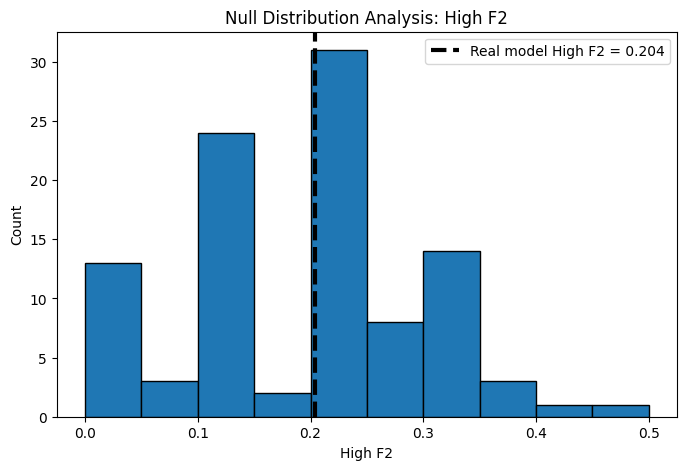

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(8, 5))

plt.hist(
    null_df["High F2"],
    bins=10,
    edgecolor="black"
)

plt.axvline(
    real_high_f2,
    linewidth=3,
    linestyle='--',
    color='black',
    label=f"Real model High F2 = {real_high_f2:.3f}"
)

plt.xlabel("High F2")
plt.ylabel("Count")
plt.title("Null Distribution Analysis: High F2")
plt.legend()
plt.show()

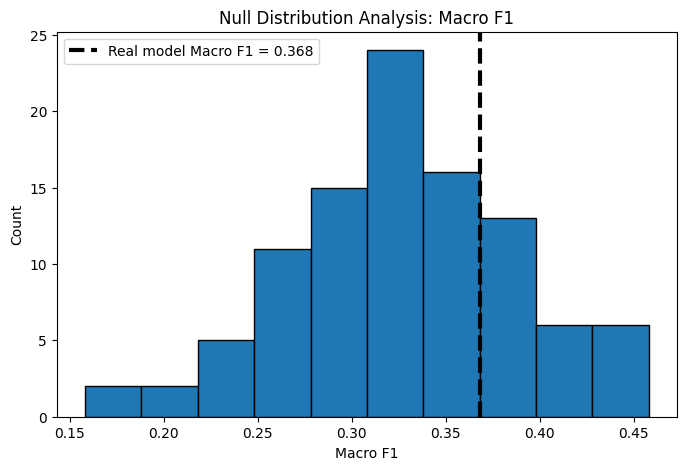

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    null_df["Macro F1"],
    bins=10,
    edgecolor="black"
)

plt.axvline(
    real_macro_f1,
    linewidth=3,
    linestyle='--',
    color='black',
    label=f"Real model Macro F1 = {real_macro_f1:.3f}"
)

plt.xlabel("Macro F1")
plt.ylabel("Count")
plt.title("Null Distribution Analysis: Macro F1")
plt.legend()
plt.show()

### 3.2 Quantitative Analysis

In [ ]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_recall_curve,
    average_precision_score
)

from sklearn.preprocessing import label_binarize

In [ ]:
labels = ["Low", "Medium", "High"]

In [ ]:
# Predictions
y_train_pred = real_model.predict(X_train)
y_test_pred = real_model.predict(X_test)

# Predicted probabilities
y_train_proba = real_model.predict_proba(X_train)
y_test_proba = real_model.predict_proba(X_test)

# Class order used by the model
model_classes = list(real_model.classes_)

print("Model class order:", model_classes)

# Sanity check: make sure all expected labels exist in model.classes_
for label in labels:
    if label not in model_classes:
        raise ValueError(f"Label '{label}' is missing from model.classes_: {model_classes}")


Model class order: ['High', 'Low', 'Medium']



Unnormalized Confusion Matrix:


,Pred Low,Pred Medium,Pred High
True Low,12,7,5
True Medium,7,8,6
True High,6,1,2


<Figure size 600x500 with 0 Axes>

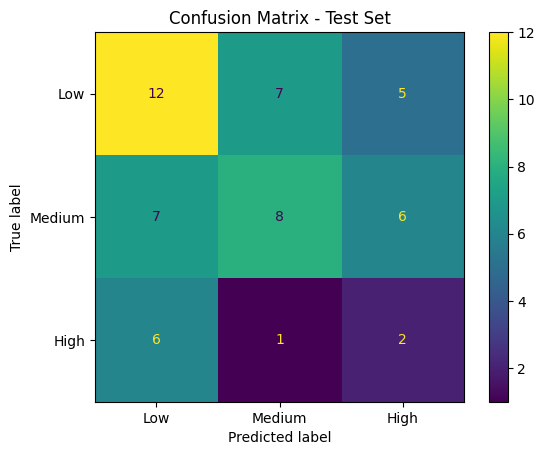

In [ ]:
# Unnormalized confusion matrix

cm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=labels
)

cm_df = pd.DataFrame(
    cm,
    index=[f"True {x}" for x in labels],
    columns=[f"Pred {x}" for x in labels]
)

print("\nUnnormalized Confusion Matrix:")
display(cm_df)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)
disp.plot(values_format="d")
plt.title("Confusion Matrix - Test Set")
plt.show()


Normalized Confusion Matrix - by True Class:


,Pred Low,Pred Medium,Pred High
True Low,0.500,0.292,0.208
True Medium,0.333,0.381,0.286
True High,0.667,0.111,0.222


<Figure size 600x500 with 0 Axes>

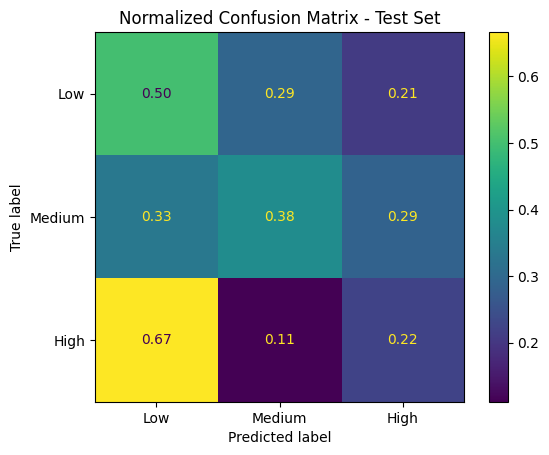

In [ ]:
# Normalized confusion matrix

cm_norm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=labels,
    normalize="true"
)

cm_norm_df = pd.DataFrame(
    cm_norm,
    index=[f"True {x}" for x in labels],
    columns=[f"Pred {x}" for x in labels]
)

print("\nNormalized Confusion Matrix - by True Class:")
display(cm_norm_df.round(3))

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=labels
)
disp.plot(values_format=".2f")
plt.title("Normalized Confusion Matrix - Test Set")
plt.show()

In [ ]:
# Category Difficulty: classification report


test_report_dict = classification_report(
    y_test,
    y_test_pred,
    labels=labels,
    output_dict=True,
    zero_division=0
)

test_report_df = pd.DataFrame(test_report_dict).T

print("\nClassification Report - Test Set:")
display(test_report_df.round(3))


Classification Report - Test Set:


,precision,recall,f1-score,support
Low,0.480,0.500,0.490,24.000
Medium,0.500,0.381,0.432,21.000
High,0.154,0.222,0.182,9.000
accuracy,0.407,0.407,0.407,0.407
macro avg,0.378,0.368,0.368,54.000
weighted avg,0.433,0.407,0.416,54.000


In [ ]:
# Train vs. Test Error Comparison


train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("\nAccuracy Comparison:")
print(f"Train Accuracy: {train_accuracy:.3f}")
print(f"Test Accuracy:  {test_accuracy:.3f}")

train_report_dict = classification_report(
    y_train,
    y_train_pred,
    labels=labels,
    output_dict=True,
    zero_division=0
)

test_report_dict = classification_report(
    y_test,
    y_test_pred,
    labels=labels,
    output_dict=True,
    zero_division=0
)

train_report_df = pd.DataFrame(train_report_dict).T
test_report_df = pd.DataFrame(test_report_dict).T

# Keep the main rows only
rows_to_compare = labels + ["macro avg", "weighted avg"]

comparison_df = pd.concat(
    {
        "Train": train_report_df.loc[rows_to_compare],
        "Test": test_report_df.loc[rows_to_compare]
    },
    axis=1
)

print("\nTrain vs. Test Classification Report:")
display(comparison_df.round(3))


# Optional: train confusion matrix
train_cm = confusion_matrix(
    y_train,
    y_train_pred,
    labels=labels
)

train_cm_df = pd.DataFrame(
    train_cm,
    index=[f"True {x}" for x in labels],
    columns=[f"Pred {x}" for x in labels]
)

print("\nTrain Confusion Matrix:")
display(train_cm_df)


print("\nTest Confusion Matrix:")
display(cm_df)


Accuracy Comparison:
Train Accuracy: 0.847
Test Accuracy:  0.407

Train vs. Test Classification Report:


Train                              Test                  \
             precision recall f1-score support precision recall f1-score   
Low              0.900  0.804    0.849   112.0     0.480  0.500    0.490   
Medium           0.778  0.863    0.818    73.0     0.500  0.381    0.432   
High             0.857  0.968    0.909    31.0     0.154  0.222    0.182   
macro avg        0.845  0.878    0.859   216.0     0.378  0.368    0.368   
weighted avg     0.853  0.847    0.847   216.0     0.433  0.407    0.416   

                      
             support  
Low             24.0  
Medium          21.0  
High             9.0  
macro avg       54.0  
weighted avg    54.0


Train Confusion Matrix:


,Pred Low,Pred Medium,Pred High
True Low,90,18,4
True Medium,9,63,1
True High,1,0,30



Test Confusion Matrix:


,Pred Low,Pred Medium,Pred High
True Low,12,7,5
True Medium,7,8,6
True High,6,1,2


In [ ]:
# Probability Distributions

proba_df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_test_pred
})

for cls in model_classes:
    cls_idx = model_classes.index(cls)
    proba_df[f"proba_{cls}"] = y_test_proba[:, cls_idx]

# Maximum probability = confidence in the selected class
proba_df["max_probability"] = np.max(y_test_proba, axis=1)

print("\nPredicted probability summary:")
display(proba_df.head())


Predicted probability summary:


,y_true,y_pred,proba_High,proba_Low,proba_Medium,max_probability
0,Medium,Low,0.310360,0.351905,0.337735,0.351905
1,Low,Low,0.238274,0.428695,0.333031,0.428695
2,High,Low,0.161898,0.501865,0.336237,0.501865
3,Low,Medium,0.161117,0.395297,0.443586,0.443586
4,Medium,Medium,0.161122,0.385281,0.453597,0.453597


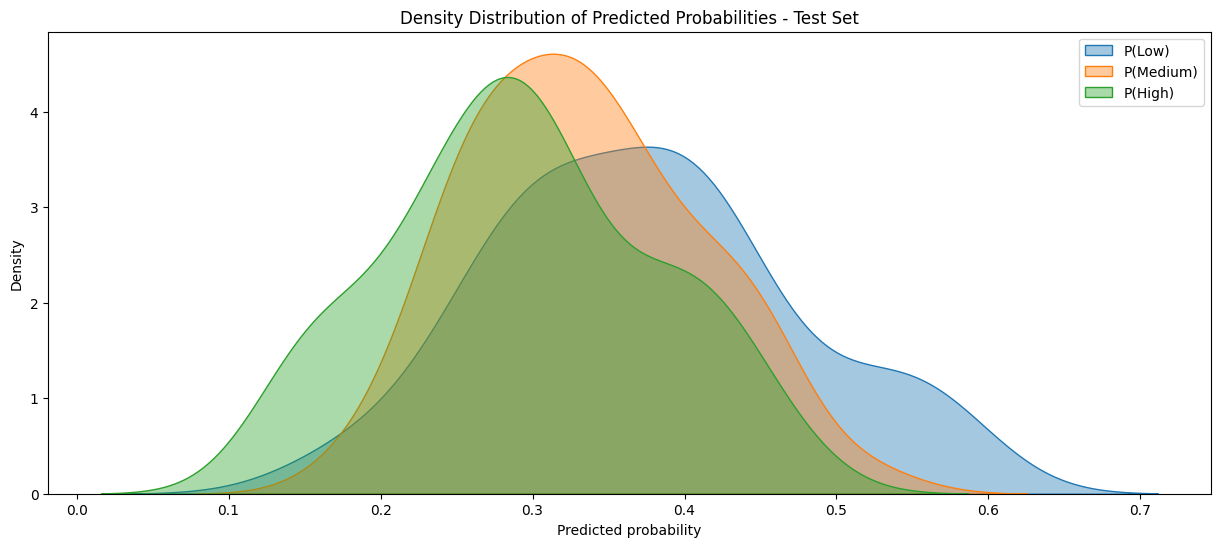

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))

for cls in labels:
    col = f"proba_{cls}"

    sns.kdeplot(
        data=proba_df,
        x=col,
        fill=True,           # Fills the area under the curve
        alpha=0.4,           # Transparency
        label=f"P({cls})"
    )

plt.xlabel("Predicted probability")
plt.ylabel("Density")
plt.title("Density Distribution of Predicted Probabilities - Test Set")
plt.legend()
plt.show()

#### 3.2.1 Predictions and Probabilities

In [ ]:
import pandas as pd
import numpy as np

y_train = train_df["CBCL_label"].values
y_test = test_df["CBCL_label"].values

# Predictions
y_pred = real_model.predict(X_test)

# Probabilities
y_proba = real_model.predict_proba(X_test)
classes = real_model.classes_

print(classes)

['High' 'Low' 'Medium']


In [ ]:
test_predictions = test_df.copy()

test_predictions["y_true"] = y_test
test_predictions["y_pred"] = y_pred

for i, cls in enumerate(classes):
    test_predictions[f"proba_{cls}"] = y_proba[:, i]

test_predictions["correct"] = (
    test_predictions["y_true"] == test_predictions["y_pred"]
)

test_predictions["error_type"] = np.where(
    test_predictions["correct"],
    "Correct",
    test_predictions["y_true"] + " -> " + test_predictions["y_pred"]
)

test_predictions[
    ["y_true", "y_pred", "correct", "error_type", "proba_High"]
].head()

,y_true,y_pred,correct,error_type,proba_High
39,Medium,Low,False,Medium -> Low,0.310360
199,Low,Low,True,Correct,0.238274
134,High,Low,False,High -> Low,0.161898
230,Low,Medium,False,Low -> Medium,0.161117
345,Medium,Medium,True,Correct,0.161122


#### 3.2.2 High-Class Probability Distribution

In [ ]:
test_predictions.groupby("y_true")["proba_High"].describe()

,count,mean,std,min,25%,50%,75%,max
y_true,,,,,,,,
High,9.0,0.286492,0.081873,0.161898,0.242512,0.257360,0.32806,0.449264
Low,24.0,0.280792,0.083458,0.133260,0.225378,0.281808,0.32498,0.419989
Medium,21.0,0.309932,0.093596,0.157683,0.243399,0.305637,0.38079,0.469381


#### 3.2.3 Error-Type Counts

In [ ]:
error_counts = (
    test_predictions["error_type"]
    .value_counts()
    .reset_index()
)

error_counts.columns = ["Error type", "Count"]

error_counts

,Error type,Count
0,Correct,22
1,Medium -> Low,7
2,Low -> Medium,7
3,High -> Low,6
4,Medium -> High,6
5,Low -> High,5
6,High -> Medium,1


### 3.3 Qualitative analysis

In [ ]:
important_errors = test_predictions[
    test_predictions["error_type"].isin([
        "High -> Low",
        "High -> Medium",
        "Medium -> Low",
        "Medium -> High",
        "Low -> Medium",
        "Low -> High"
    ])
].copy()

important_errors = important_errors[
    [
        "y_true",
        "y_pred",
        "proba_Low",
        "proba_Medium",
        "proba_High",
        "CBCL_score",
        "Event",
        "EER_text"
    ]
]

important_errors

,y_true,y_pred,proba_Low,proba_Medium,proba_High,CBCL_score,Event,EER_text
134,High,Low,0.501865,0.336237,0.161898,46.0,"פחדים חרדות , אי שקט קושי בשינה","יהיו ימים טובים , כל החטופים יחזרו הביתה בשלום..."
230,Low,Medium,0.395297,0.443586,0.161117,13.0,חוסר הרצון של הילדים ללכת לבית ספר. תחושה שלהם...,הכל זמני וזה יעבור\nתמשיכי לדבר עם הילדים ולהס...
72,Low,Medium,0.279503,0.445445,0.275052,4.0,ריצה לממד בעת האזעקה. כאב לי הדריכות של בן ה 5...,"את עושה מה שאפשר להגן על הילדים, אתם בסביבה בט..."
471,High,Low,0.456664,0.239662,0.303674,32.0,"בזמן אזעקה מחוץ לבית עם יךדי הקטניפ , הרגשה של...",מצטער צאוד אך קשה לי עם זה
654,Low,High,0.343664,0.276240,0.380096,12.0,הוצאת התסכולים והחרדות מהמלחמה על הילדים,"צריך לחמול לעצמך יותר, זה מצב קשה שלא היית בו ..."
426,Low,Medium,0.311835,0.388321,0.299844,1.0,כל המצב של המלחמה במיוחד האזעקות מלחיצות מאוד ...,הילדים לא צריכים לחוות כאלו דברים בילדות.\nחבל...
298,High,Low,0.405761,0.351727,0.242512,44.0,המטפלת של הבת שלי התקשרה ושיתפה שהסת ךשי שיתפה...,את אמא טובה. פשוט טובה. את רואה את הבת שלך ונו...
341,Low,Medium,0.220507,0.522705,0.256788,12.0,הילדים שלי נבהלו מהאזעקה ופחדו לישון לבד. היה ...,"היי לך, \nהילדים יצליחו להתגבר, וברגע שהמלחמה ..."
418,Low,High,0.293297,0.286715,0.419989,3.0,הילדים שלי מפחדים מהזעקות שחיזבלה יורים,"אין לי הרבה מה לתאר , רק לחבק אותם שהם מפחדים"
262,High,Medium,0.315164,0.431642,0.253195,55.0,בגלל המערכה נאלצתי לחפש תעסוקה לילדים שלי בגלל...,אני משלים עם העובדה שזה מצב זמני ושמתישהו המער...


In [ ]:
for i, row in important_errors.iterrows():
    print("=" * 100)
    print("TRUE:", row["y_true"], "| PRED:", row["y_pred"])
    print("CBCL score:", row["CBCL_score"])
    print("P(Low):", round(row["proba_Low"], 3),
          "P(Medium):", round(row["proba_Medium"], 3),
          "P(High):", round(row["proba_High"], 3))
    print("\nEVENT:")
    print(row["Event"])
    print("\nEER_TEXT:")
    print(row["EER_text"])

TRUE: High | PRED: Low
CBCL score: 46.0
P(Low): 0.502 P(Medium): 0.336 P(High): 0.162

EVENT:
פחדים חרדות , אי שקט קושי בשינה 

EER_TEXT:
יהיו ימים טובים , כל החטופים יחזרו הביתה בשלום 
שלא יהיו לנו אויבים 
TRUE: Low | PRED: Medium
CBCL score: 13.0
P(Low): 0.395 P(Medium): 0.444 P(High): 0.161

EVENT:
חוסר הרצון של הילדים ללכת לבית ספר. תחושה שלהם של נתק ואי הבנה למה צריך ללמוד

EER_TEXT:
הכל זמני וזה יעבור
תמשיכי לדבר עם הילדים ולהסביר להם את חשיבות הלמידה הפרונטלית גם בתקופה זו
TRUE: Low | PRED: Medium
CBCL score: 4.0
P(Low): 0.28 P(Medium): 0.445 P(High): 0.275

EVENT:
ריצה לממד בעת האזעקה. כאב לי הדריכות של בן ה 5 , שכבר מתורגל ולא שואל שאלות. וההלם של בת השנתיים שקפצה אגרופים

EER_TEXT:
את עושה מה שאפשר להגן על הילדים, אתם בסביבה בטוחה. את אמנם מרגישה שהקרקע בוערת, שזה יכול להשתנות, שאחרי הזוועות של ה 7.10 הכל יכול לקרות ואף אחד לא מוגן. אבל את חייבת להיות חזקה בשבילם, לעשות כל מה שאפשר להגן עליהם ולקוות לטוב. 
TRUE: High | PRED: Low
CBCL score: 32.0
P(Low): 0.457 P(Medium): 0.24 

### 3.4 Sensitivity Analysis

To evaluate robustness to small perturbations in the learned representations, Gaussian noise is added separately to the Event embeddings, EER_text embeddings, and both feature groups. Performance is evaluated across multiple noise levels and random seeds using Macro F1 and High-class F2.

In [ ]:
EMBEDDING_DIM = 768

def add_noise(X, noise_std=0.05, feature_group="all", random_state=42):
    """
    Add Gaussian noise to selected parts of the embedding matrix.

    feature_group:
    - "event": add noise only to Event embedding
    - "eer": add noise only to EER_text embedding
    - "all": add noise to both
    """

    rng = np.random.default_rng(random_state)

    X_noisy = X.copy()

    if feature_group == "event":
        cols = np.arange(0, EMBEDDING_DIM)

    elif feature_group == "eer":
        cols = np.arange(EMBEDDING_DIM, X.shape[1])

    elif feature_group == "all":
        cols = np.arange(0, X.shape[1])

    else:
        raise ValueError("feature_group must be: 'event', 'eer', or 'all'")

    noise = rng.normal(
        loc=0,
        scale=noise_std,
        size=X_noisy[:, cols].shape
    )

    X_noisy[:, cols] = X_noisy[:, cols] + noise

    return X_noisy

In [ ]:
noise_levels = [0.01, 0.03, 0.05, 0.10, 0.20]
feature_groups = ["event", "eer", "all"]

rows = []

# Add original baseline row
rows.append({
    "Feature group": "none",
    "Noise std": 0,
    "Macro F1": real_results["Macro F1"],
    "High Precision": real_results["High Precision"],
    "High Recall": real_results["High Recall"],
    "High F2": real_results["High F2"]
})

for group in feature_groups:
    for noise_std in noise_levels:

        X_test_noisy = add_noise(
            X_test,
            noise_std=noise_std,
            feature_group=group,
            random_state=42
        )

        y_pred_noisy = real_model.predict(X_test_noisy)

        results = evaluate_model(
            f"Noise={noise_std}, group={group}",
            y_test,
            y_pred_noisy
        )

        rows.append({
            "Feature group": group,
            "Noise std": noise_std,
            "Macro F1": results["Macro F1"],
            "High Precision": results["High Precision"],
            "High Recall": results["High Recall"],
            "High F2": results["High F2"]
        })

noise_df = pd.DataFrame(rows)

noise_df

,Feature group,Noise std,Macro F1,High Precision,High Recall,High F2
0,none,0.00,0.368016,0.153846,0.222222,0.204082
1,event,0.01,0.319694,0.076923,0.111111,0.102041
2,event,0.03,0.379976,0.214286,0.333333,0.300000
3,event,0.05,0.358025,0.222222,0.444444,0.370370
4,event,0.10,0.338047,0.190476,0.444444,0.350877
5,event,0.20,0.344697,0.217391,0.555556,0.423729
6,eer,0.01,0.411077,0.200000,0.222222,0.217391
7,eer,0.03,0.427407,0.222222,0.222222,0.222222
8,eer,0.05,0.369295,0.200000,0.222222,0.217391
9,eer,0.10,0.370851,0.153846,0.222222,0.204082


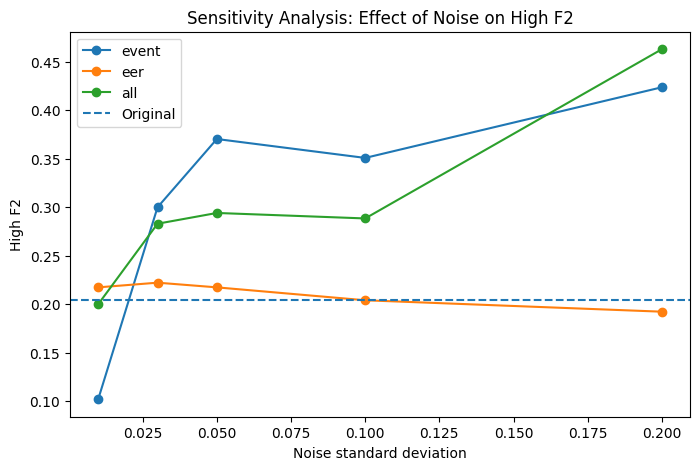

In [ ]:
import matplotlib.pyplot as plt

plot_df = noise_df[noise_df["Feature group"] != "none"]

plt.figure(figsize=(8, 5))

for group in feature_groups:
    subset = plot_df[plot_df["Feature group"] == group]

    plt.plot(
        subset["Noise std"],
        subset["High F2"],
        marker="o",
        label=group
    )

plt.axhline(
    real_results["High F2"],
    linestyle="--",
    label="Original"
)

plt.xlabel("Noise standard deviation")
plt.ylabel("High F2")
plt.title("Sensitivity Analysis: Effect of Noise on High F2")
plt.legend()
plt.show()

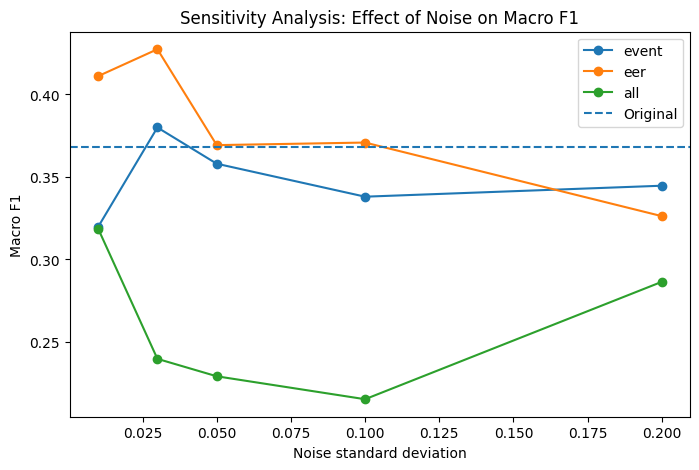

In [ ]:
plt.figure(figsize=(8, 5))

for group in feature_groups:
    subset = plot_df[plot_df["Feature group"] == group]

    plt.plot(
        subset["Noise std"],
        subset["Macro F1"],
        marker="o",
        label=group
    )

plt.axhline(
    real_results["Macro F1"],
    linestyle="--",
    label="Original"
)

plt.xlabel("Noise standard deviation")
plt.ylabel("Macro F1")
plt.title("Sensitivity Analysis: Effect of Noise on Macro F1")
plt.legend()
plt.show()

#### Repeated Noise Perturbation Across Random Seeds

In [ ]:
noise_levels = [0.01, 0.03, 0.05, 0.10, 0.20]
feature_groups = ["event", "eer", "all"]
seeds = range(20)

rows = []

for group in feature_groups:
    for noise_std in noise_levels:
        for seed in seeds:

            X_test_noisy = add_noise(
                X_test,
                noise_std=noise_std,
                feature_group=group,
                random_state=seed
            )

            y_pred_noisy = real_model.predict(X_test_noisy)

            results = evaluate_model(
                f"Noise={noise_std}, group={group}, seed={seed}",
                y_test,
                y_pred_noisy
            )

            rows.append({
                "Feature group": group,
                "Noise std": noise_std,
                "Seed": seed,
                "Macro F1": results["Macro F1"],
                "High Precision": results["High Precision"],
                "High Recall": results["High Recall"],
                "High F2": results["High F2"]
            })

noise_repeated_df = pd.DataFrame(rows)

noise_summary = (
    noise_repeated_df
    .groupby(["Feature group", "Noise std"])
    .agg(
        Macro_F1_mean=("Macro F1", "mean"),
        Macro_F1_std=("Macro F1", "std"),
        High_F2_mean=("High F2", "mean"),
        High_F2_std=("High F2", "std"),
        High_Recall_mean=("High Recall", "mean"),
        High_Recall_std=("High Recall", "std"),
        High_Precision_mean=("High Precision", "mean"),
        High_Precision_std=("High Precision", "std")
    )
    .reset_index()
)

noise_summary

,Feature group,Noise std,Macro_F1_mean,Macro_F1_std,High_F2_mean,High_F2_std,High_Recall_mean,High_Recall_std,High_Precision_mean,High_Precision_std
0,all,0.01,0.356778,0.027597,0.167459,0.054509,0.177778,0.055847,0.137294,0.051199
1,all,0.03,0.341832,0.040646,0.220996,0.081155,0.244444,0.092612,0.164805,0.061498
2,all,0.05,0.328080,0.058255,0.231626,0.110992,0.266667,0.131962,0.154778,0.071650
3,all,0.10,0.328700,0.051248,0.261413,0.113632,0.311111,0.142383,0.162681,0.066158
4,all,0.20,0.326218,0.070317,0.292412,0.133288,0.355556,0.167542,0.174552,0.078048
5,eer,0.01,0.350783,0.020038,0.158471,0.049810,0.172222,0.056713,0.120936,0.033869
6,eer,0.03,0.343348,0.045617,0.186606,0.094618,0.205556,0.109787,0.139314,0.063603
7,eer,0.05,0.332065,0.062422,0.193263,0.124969,0.216667,0.150697,0.140962,0.081975
8,eer,0.10,0.352876,0.070230,0.263009,0.120404,0.300000,0.144647,0.183057,0.081496
9,eer,0.20,0.338665,0.062414,0.255531,0.118067,0.300000,0.144647,0.165425,0.074423


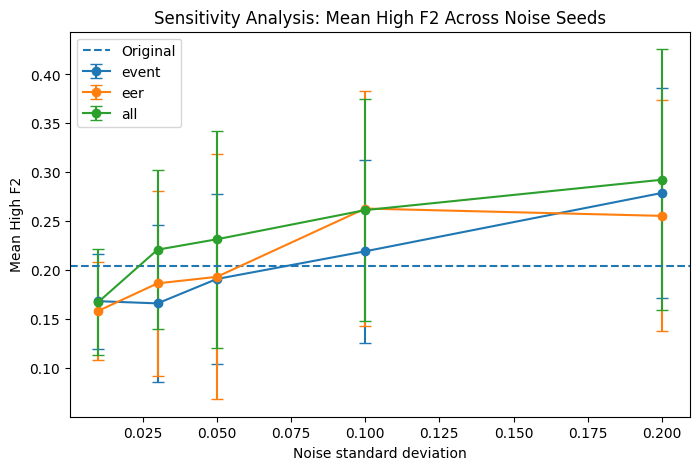

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for group in feature_groups:
    subset = noise_summary[noise_summary["Feature group"] == group]

    plt.errorbar(
        subset["Noise std"],
        subset["High_F2_mean"],
        yerr=subset["High_F2_std"],
        marker="o",
        capsize=4,
        label=group
    )

plt.axhline(
    real_results["High F2"],
    linestyle="--",
    label="Original"
)

plt.xlabel("Noise standard deviation")
plt.ylabel("Mean High F2")
plt.title("Sensitivity Analysis: Mean High F2 Across Noise Seeds")
plt.legend()
plt.show()

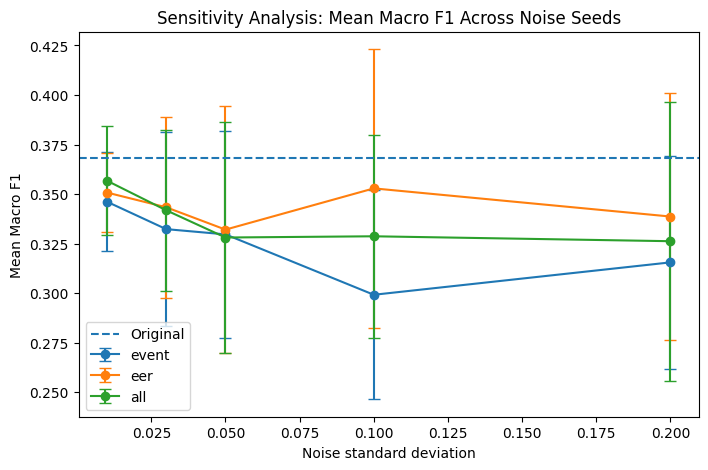

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for group in feature_groups:
    subset = noise_summary[noise_summary["Feature group"] == group]

    plt.errorbar(
        subset["Noise std"],
        subset["Macro_F1_mean"],
        yerr=subset["Macro_F1_std"],
        marker="o",
        capsize=4,
        label=group
    )

plt.axhline(
    real_results["Macro F1"],
    linestyle="--",
    label="Original"
)

plt.xlabel("Noise standard deviation")
plt.ylabel("Mean Macro F1")
plt.title("Sensitivity Analysis: Mean Macro F1 Across Noise Seeds")
plt.legend()
plt.show()